In [1]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.layers import Dense, Input, BatchNormalization, Dropout, Add, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

2026-03-17 05:18:52.206361: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773724732.612053      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773724732.716848      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773724733.730837      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773724733.730878      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773724733.730881      55 computation_placer.cc:177] computation placer alr

In [2]:
# 2. Load Dataset
df = pd.read_csv("/kaggle/input/datasets/dhivyeshrk/diseases-and-symptoms-dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv")   # change to your dataset path
print(df.head())

         diseases  anxiety and nervousness  depression  shortness of breath  \
0  panic disorder                        1           0                    1   
1  panic disorder                        0           0                    1   
2  panic disorder                        1           1                    1   
3  panic disorder                        1           0                    0   
4  panic disorder                        1           1                    0   

   depressive or psychotic symptoms  sharp chest pain  dizziness  insomnia  \
0                                 1                 0          0         0   
1                                 1                 0          1         1   
2                                 1                 0          1         1   
3                                 1                 0          1         1   
4                                 0                 0          0         1   

   abnormal involuntary movements  chest tightness  ... 

In [3]:
# 3. Split Features and Target

X = df.drop("diseases", axis=1)   # all symptoms
y = df["diseases"]                # disease label

In [4]:
# 4. Encode Target Labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
num_classes = len(np.unique(y))

In [5]:
# 5. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [6]:
# 6. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
# 7. Residual Block Definition

def residual_block(x, units):

    shortcut = x

    x = Dense(units, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(units, activation=None)(x)
    x = BatchNormalization()(x)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x

In [8]:
# 8. Build Residual MLP Model
input_dim = X_train.shape[1]

inputs = Input(shape=(input_dim,))

x = Dense(256, activation='relu')(inputs)
x = BatchNormalization()(x)

# Residual Blocks
x = residual_block(x, 256)
x = residual_block(x, 256)

x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1773724778.431825      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773724778.437990      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 377)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     96,768 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256)       │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     65,792 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256)       │          0 │ batch_normalizat… │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256)       │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 498,181 (1.90 MB)

 Trainable params: 495,365 (1.89 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [9]:
# 9. Train Model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


I0000 00:00:1773724784.643708     125 service.cc:152] XLA service 0x7a76a009a340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773724784.643745     125 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773724784.643749     125 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773724785.457167     125 cuda_dnn.cc:529] Loaded cuDNN version 91002


  53/4939 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.0042 - loss: 6.7362      

I0000 00:00:1773724788.679502     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4939/4939 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - accuracy: 0.5711 - loss: 2.2509 - val_accuracy: 0.8306 - val_loss: 0.5125
Epoch 2/50
4939/4939 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.8069 - loss: 0.6502 - val_accuracy: 0.8412 - val_loss: 0.4563
Epoch 3/50
4939/4939 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.8212 - loss: 0.5761 - val_accuracy: 0.8416 - val_loss: 0.4465
Epoch 4/50
4939/4939 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.8331 - loss: 0.5298 - val_accuracy: 0.8505 - val_loss: 0.4159
Epoch 5/50
4939/4939 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.8372 - loss: 0.5041 - val_accuracy: 0.8513 - val_loss: 0.4119
Epoch 6/50
4939/4939 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8435 - loss: 0.4836 - val_accuracy: 0.8505 - val_loss: 0.4035
Epoch 7/50
4939/4939 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.8418 - loss: 0.4764 - val_accuracy: 0.8498 - val_loss: 0.4018
Epoch 8/50
4939/4939 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.8462 - loss: 0.4640 - val

In [10]:
# 10. Model Evaluation
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

1544/1544 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Accuracy: 0.8543400352305169

Classification Report:

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        20
           1       0.92      0.99      0.95        81
           2       0.58      0.90      0.70        58
           3       1.00      0.83      0.91         6
           4       0.94      0.94      0.94        63
           5       1.00      0.50      0.67         6
           6       0.80      0.80      0.80         5
           7       0.70      0.80      0.74        20
           8       1.00      0.65      0.79       103
           9       0.75      0.82      0.78       179
          10       0.83      0.93      0.88       253
          11       0.89      0.68      0.77       221
          12       0.73      0.75      0.74       187
          13       0.50      1.00      0.67         3
          14       0.60      0.39      0.47        31
          15       0.96      0.95     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [11]:
!pip install shap

SHAP Summary for abdominal aortic aneurysm


/tmp/ipykernel_55/3155047663.py:32: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


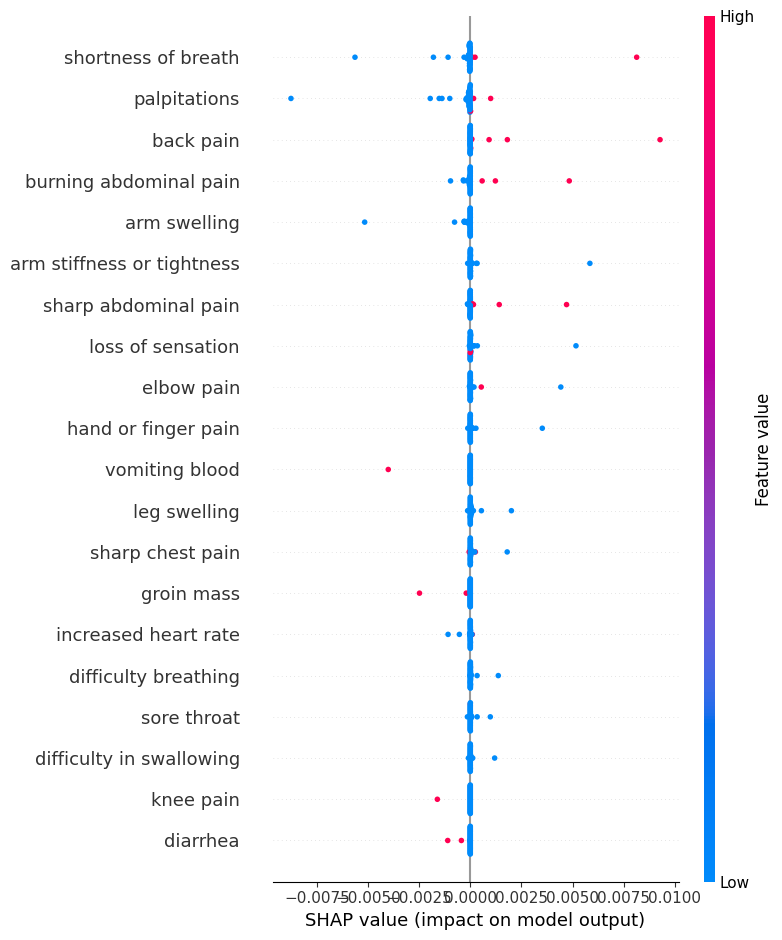

SHAP Summary for abdominal hernia


/tmp/ipykernel_55/3155047663.py:32: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


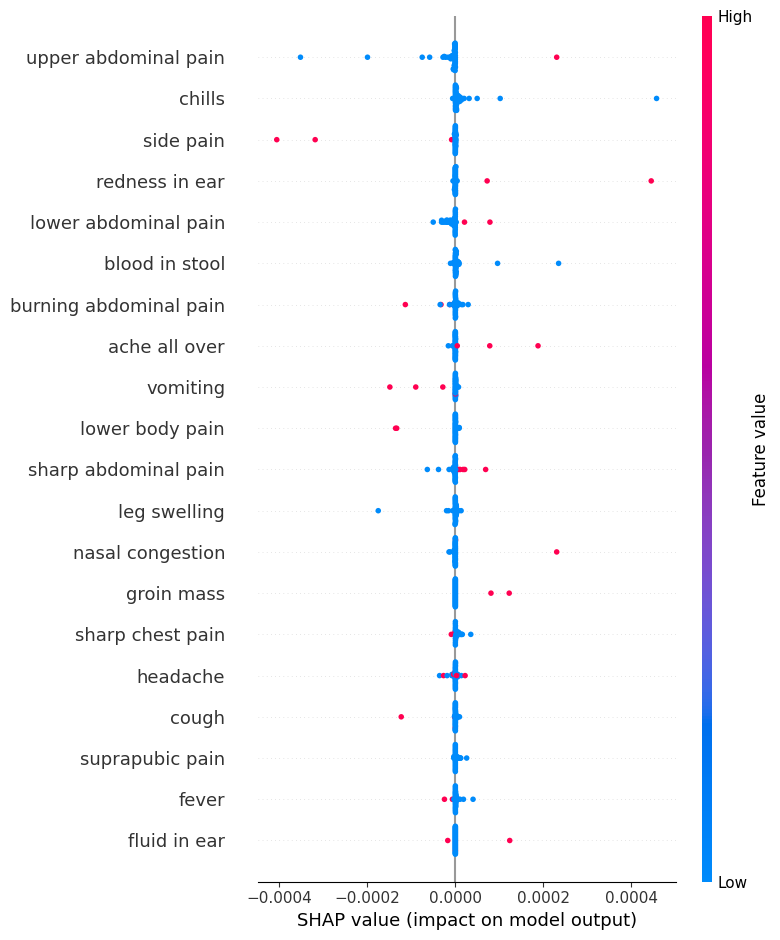

SHAP Summary for abscess of nose


/tmp/ipykernel_55/3155047663.py:32: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


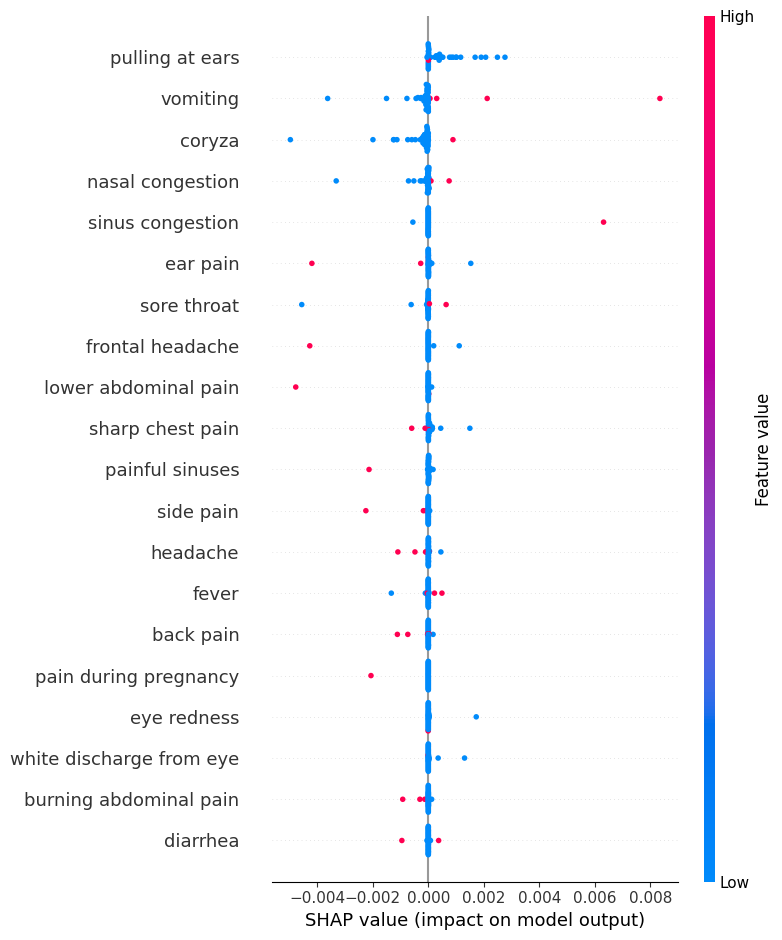

SHAP Summary for abscess of the lung


/tmp/ipykernel_55/3155047663.py:32: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


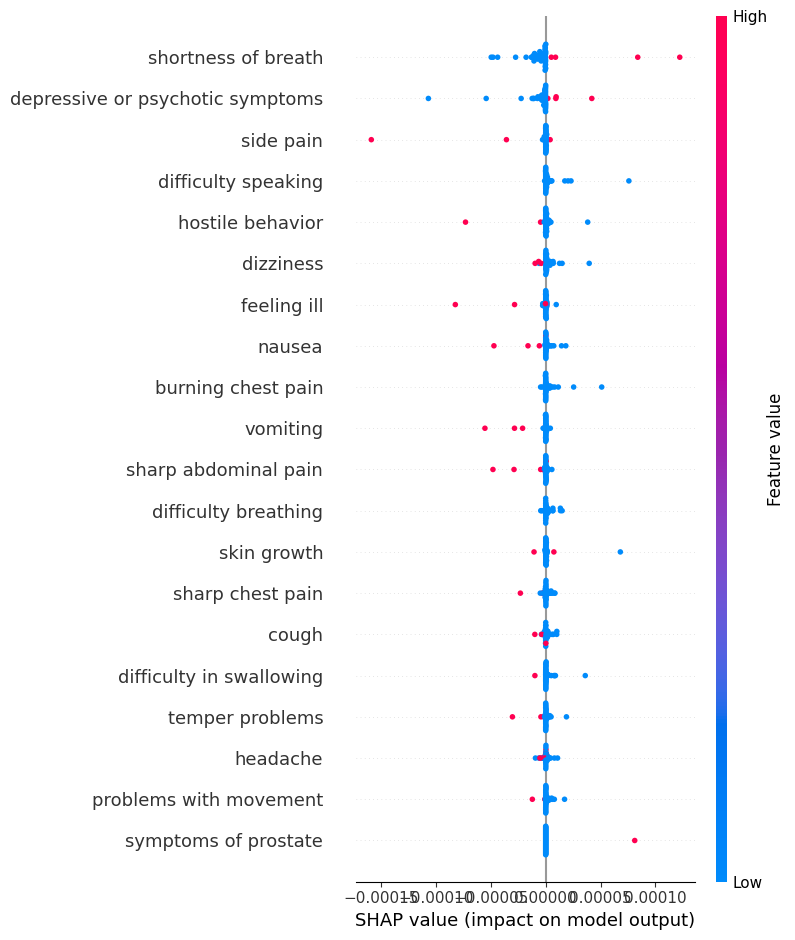

SHAP Summary for abscess of the pharynx


/tmp/ipykernel_55/3155047663.py:32: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


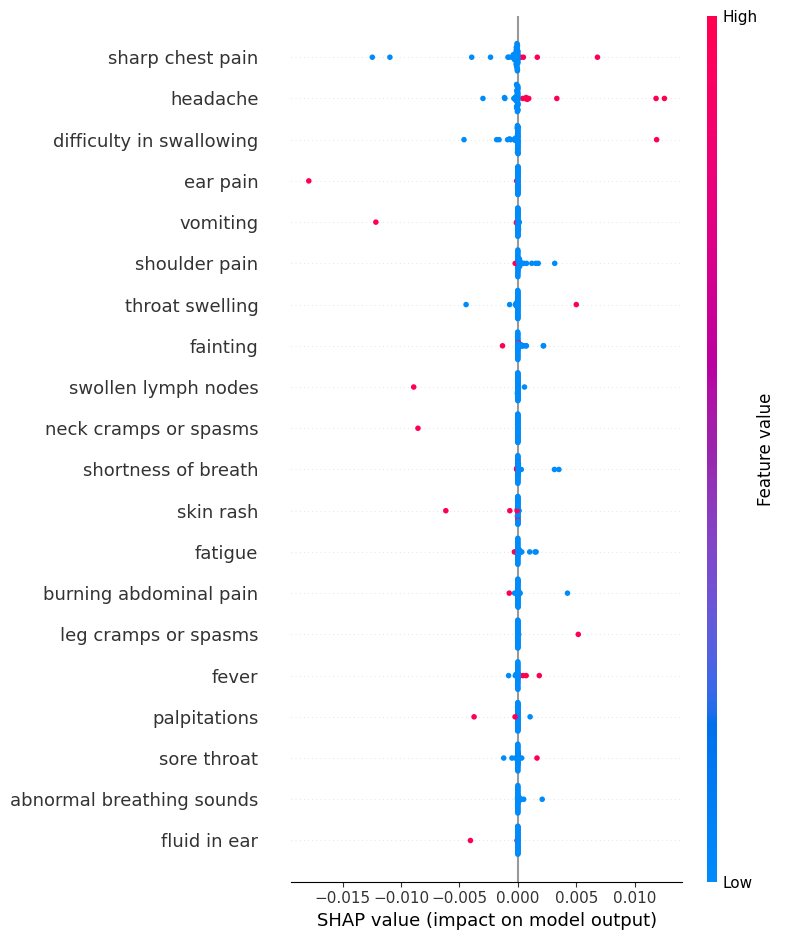

In [17]:
import shap
import numpy as np

# Keep everything as NumPy (IMPORTANT)
X_train_np = X_train.astype(np.float32)
X_test_np = X_test.astype(np.float32)

# Background samples
background = X_train_np[
    np.random.choice(X_train_np.shape[0], 100, replace=False)
]

# Explainer
explainer = shap.GradientExplainer(
    model,
    background
)

# Samples
X_shap = X_test_np[:50]

# SHAP values
shap_values = explainer.shap_values(X_shap)

feature_names = df.drop("diseases", axis=1).columns

# Plot
for i, class_name in enumerate(label_encoder.classes_[:5]):
    
    print(f"SHAP Summary for {class_name}")
    
    shap.summary_plot(
        shap_values[:, :, i],
        X_shap,
        feature_names=feature_names
    )

In [18]:
# 11. Save Model
model.save("residual_mlp_model.h5")

print("Model saved successfully!")

Model saved successfully!
